# Startie Core Tables EDA + Data Integrity

Target tables:
- `users`
- `event_logs`
- `payment_transactions`
- `plan_history`
- `lessons`

Purpose:
- Understand table structure and distributions for Q1 analysis
- Validate data integrity before KPI/OMTM calculation


In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')


## 1) Locate data directory

In [3]:
required = [
    'users.csv',
    'event_logs.csv',
    'payment_transactions.csv',
    'plan_history.csv',
    'lessons.csv'
]

cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
DATA_DIR = None

for d in search_roots:
    candidate = d / 'data' / 'raw'
    if candidate.exists() and all((candidate / f).exists() for f in required):
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        f'Could not locate data/raw with required files from cwd={cwd}'
    )

print(f'DATA_DIR: {DATA_DIR}')
DATA_DIR


DATA_DIR: C:\Users\user\hoon\projects\startie_product_analysis\data\raw


WindowsPath('C:/Users/user/hoon/projects/startie_product_analysis/data/raw')

## 2) Load data

In [4]:
users = pd.read_csv(
    DATA_DIR / 'users.csv',
    parse_dates=['signup_date', 'plan_start_date', 'activation_date', 'churn_date', 'last_active_date']
)

event_logs = pd.read_csv(
    DATA_DIR / 'event_logs.csv',
    parse_dates=['event_timestamp'],
    dtype={
        'event_name': 'category',
        'device_type': 'category',
        'location': 'category',
        'page_name': 'category'
    }
)

payments = pd.read_csv(
    DATA_DIR / 'payment_transactions.csv',
    parse_dates=['transaction_date']
)

plan_history = pd.read_csv(
    DATA_DIR / 'plan_history.csv',
    parse_dates=['action_date']
)

lessons = pd.read_csv(DATA_DIR / 'lessons.csv')

print('Loaded all tables.')


Loaded all tables.


## 3) Quick profiling helpers

In [5]:
event_logs.head()

,user_id,session_id,event_name,event_timestamp,device_type,location,event_sequence,page_name,course_id,lesson_id,event_properties
0,U-02330,S-d93df4dcbfa3,session_started,2025-01-06 00:11:00,ios,South Korea,1,NaN,NaN,NaN,NaN
1,U-02330,S-d93df4dcbfa3,page_viewed,2025-01-06 00:13:44,ios,South Korea,2,home,NaN,NaN,NaN
2,U-02330,S-d93df4dcbfa3,course_searched,2025-01-06 00:15:43,ios,South Korea,3,NaN,NaN,NaN,"{""search_keyword"": ""chatgpt"", ""result_count"": 7}"
3,U-02330,S-d93df4dcbfa3,session_ended,2025-01-06 00:18:28,ios,South Korea,4,NaN,NaN,NaN,NaN
4,U-00679,S-9f84670f02e6,session_started,2025-01-06 03:19:54,web,South Korea,1,NaN,NaN,NaN,NaN


In [6]:
def profile_df(df, name):
    prof = pd.DataFrame({
        'column': df.columns,
        'dtype': [str(df[c].dtype) for c in df.columns],
        'null_count': [df[c].isna().sum() for c in df.columns],
        'null_pct': [round(df[c].isna().mean() * 100, 2) for c in df.columns],
        'nunique': [df[c].nunique(dropna=True) for c in df.columns],
    })
    print(f'[{name}] rows={len(df):,}, cols={df.shape[1]}, memory={df.memory_usage(deep=True).sum()/1024**2:,.2f} MB')
    return prof.sort_values(['null_pct', 'nunique'], ascending=[False, False]).reset_index(drop=True)


def top_counts(df, col, n=10):
    return df[col].value_counts(dropna=False).head(n).to_frame('count')


## 4) Table profiles

In [7]:
users_profile = profile_df(users, 'users')
users_profile

[users] rows=19,050, cols=19, memory=12.98 MB


,column,dtype,null_count,null_pct,nunique
0,activation_date,datetime64[ns],15908,83.51,381
1,plan_start_date,datetime64[ns],13523,70.99,382
2,current_plan,object,13523,70.99,4
3,cancel_reason,object,10494,55.09,8
4,churn_date,datetime64[ns],8308,43.61,430
5,campaign_id,object,3801,19.95,13
6,user_id,object,0,0.00,19050
7,signup_date,datetime64[ns],0,0.00,451
8,last_active_date,datetime64[ns],0,0.00,425
9,total_sessions,int64,0,0.00,126


In [8]:
### 대부분의 유저가 활성화 상태가 아님 -> 활성화 기준이 넘 빡셈 이렇게 되면  
### 활성화 기준을 acqusition에서 단계 이후 첫 강의 시작 -> 완료 인지 완료 -> 퀴즈인지 구간을 보고 
### 활성화 기준을 강의1+퀴즈0, 강의1 + 퀴즈1 강의2 퀴즈1 이런식으로 같이 봐서 기준을 선택하는 것도 좋을 듯
### 70%의 사람이 유료플랜을 하지 않음! 
### 이탈 분석 시 55%임 

In [9]:
event_profile = profile_df(event_logs, 'event_logs')
event_profile

[event_logs] rows=1,125,942, cols=11, memory=309.23 MB


,column,dtype,null_count,null_pct,nunique
0,lesson_id,object,896124,79.59,239
1,course_id,object,805958,71.58,20
2,event_properties,object,782443,69.49,6289
3,page_name,category,780263,69.30,14
4,session_id,object,9007,0.80,201081
5,event_timestamp,datetime64[ns],0,0.00,1001044
6,user_id,object,0,0.00,17020
7,event_name,category,0,0.00,21
8,event_sequence,int64,0,0.00,15
9,device_type,category,0,0.00,3


In [10]:
payments_profile = profile_df(payments, 'payment_transactions')
payments_profile

[payment_transactions] rows=8,177, cols=10, memory=3.57 MB


,column,dtype,null_count,null_pct,nunique
0,failure_reason,object,7792,95.29,5
1,transaction_id,object,0,0.00,8177
2,user_id,object,0,0.00,5002
3,transaction_date,datetime64[ns],0,0.00,143
4,plan_name,object,0,0.00,4
5,amount,int64,0,0.00,4
6,status,object,0,0.00,2
7,retry_count,int64,0,0.00,2
8,currency,object,0,0.00,1
9,payment_method,object,0,0.00,1


In [11]:
plan_profile = profile_df(plan_history, 'plan_history')
plan_profile

[plan_history] rows=8,585, cols=6, memory=2.22 MB


,column,dtype,null_count,null_pct,nunique
0,cancel_reason,object,8492,98.92,6
1,previous_plan,object,8478,98.75,2
2,user_id,object,0,0.00,5520
3,action_date,datetime64[ns],0,0.00,387
4,plan_name,object,0,0.00,4
5,action,object,0,0.00,4


In [12]:
lessons_profile = profile_df(lessons, 'lessons')
lessons_profile

[lessons] rows=239, cols=6, memory=0.06 MB


,column,dtype,null_count,null_pct,nunique
0,lesson_id,object,0,0.0,239
1,title,object,0,0.0,76
2,duration_min,int64,0,0.0,26
3,course_id,object,0,0.0,20
4,lesson_order,int64,0,0.0,20
5,has_quiz,bool,0,0.0,2


## 5) Date coverage

In [13]:
date_summary = pd.DataFrame([
    ['users.signup_date', users['signup_date'].min(), users['signup_date'].max()],
    ['users.last_active_date', users['last_active_date'].min(), users['last_active_date'].max()],
    ['event_logs.event_timestamp', event_logs['event_timestamp'].min(), event_logs['event_timestamp'].max()],
    ['payments.transaction_date', payments['transaction_date'].min(), payments['transaction_date'].max()],
    ['plan_history.action_date', plan_history['action_date'].min(), plan_history['action_date'].max()],
], columns=['field', 'min_date', 'max_date'])

date_summary


,field,min_date,max_date
0,users.signup_date,2024-03-01 00:00:00,2025-05-25 00:00:00
1,users.last_active_date,2024-03-15 00:00:00,2025-05-25 00:00:00
2,event_logs.event_timestamp,2025-01-06 00:11:00,2025-05-26 00:08:27
3,payments.transaction_date,2025-01-06 00:00:00,2025-05-28 00:00:00
4,plan_history.action_date,2024-03-08 00:00:00,2025-05-25 00:00:00


## 6) EDA by table

In [14]:
# users
print(top_counts(users, 'state', 10))
print(top_counts(users, 'acquisition_source', 10))
print(top_counts(users, 'device_type', 10))


             count
state             
churned       9122
active        3835
free_active   3285
resurrected   1620
trialing      1188
                      count
acquisition_source         
google_ads             3816
organic                3801
youtube                3378
content_marketing      2746
meta_ads               2320
referral               1517
instagram_influencer   1472
             count
device_type       
web           8516
ios           5660
android       4874


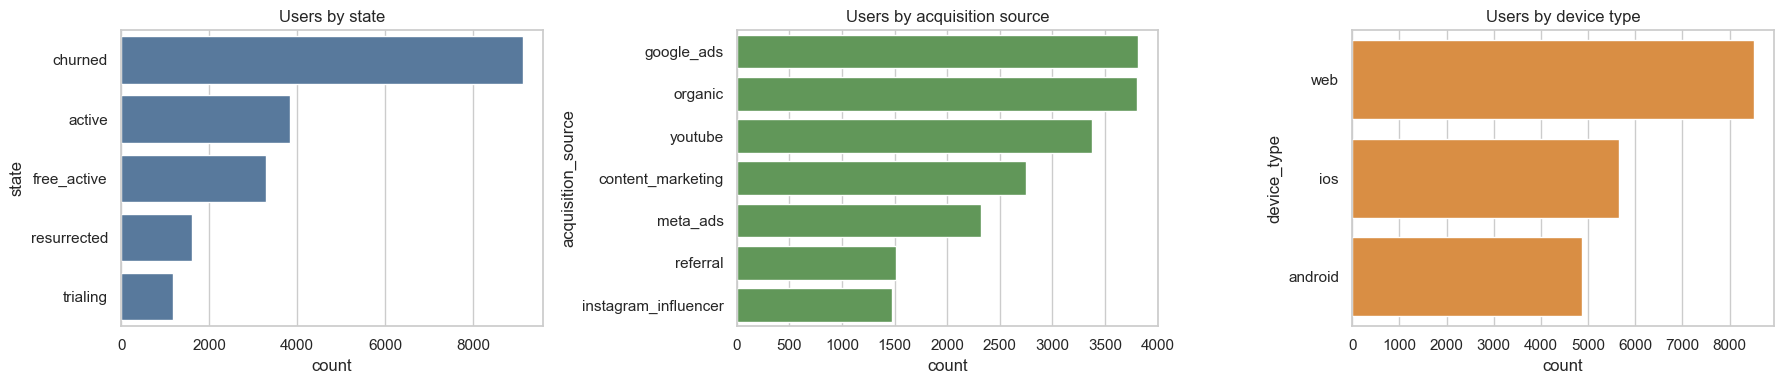

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=users, y='state', order=users['state'].value_counts().index, ax=axes[0], color='#4C78A8')
axes[0].set_title('Users by state')

sns.countplot(data=users, y='acquisition_source', order=users['acquisition_source'].value_counts().index, ax=axes[1], color='#59A14F')
axes[1].set_title('Users by acquisition source')

sns.countplot(data=users, y='device_type', order=users['device_type'].value_counts().index, ax=axes[2], color='#F28E2B')
axes[2].set_title('Users by device type')

plt.tight_layout()


In [16]:
# Q1 baseline signal: activation -> paid conversion
paid_users = set(payments.loc[payments['status'] == 'completed', 'user_id'].unique())
user_paid = users['user_id'].isin(paid_users)

activation_rate = users['is_activated'].mean()
overall_paid_conv = user_paid.mean()
activated_paid_conv = user_paid[users['is_activated'] == True].mean()
non_activated_paid_conv = user_paid[users['is_activated'] == False].mean()

pd.DataFrame({
    'metric': ['activation_rate', 'overall_paid_conversion', 'activated_paid_conversion', 'non_activated_paid_conversion', 'lift_x'],
    'value': [
        activation_rate,
        overall_paid_conv,
        activated_paid_conv,
        non_activated_paid_conv,
        activated_paid_conv / max(non_activated_paid_conv, 1e-9)
    ]
})


,metric,value
0,activation_rate,0.164934
1,overall_paid_conversion,0.256955
2,activated_paid_conversion,0.573520
3,non_activated_paid_conversion,0.194430
4,lift_x,2.949744


In [17]:
# event_logs
top_counts(event_logs, 'event_name', 20)


,count
event_name,
page_viewed,252508
session_ended,202084
session_started,202071
lesson_started,109568
lesson_completed,107064
course_detail_viewed,74520
course_searched,47343
onboarding_step_completed,29062
pricing_page_viewed,15088


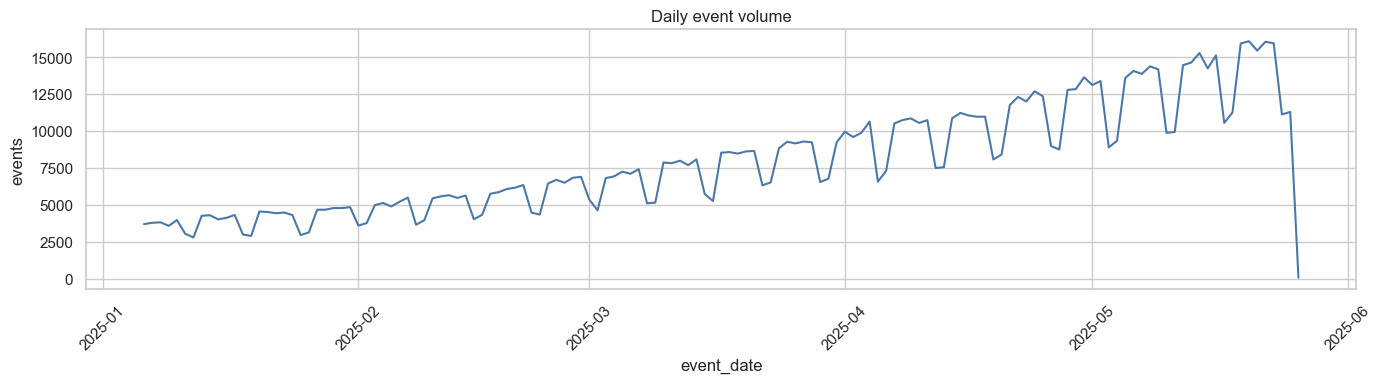

In [18]:
daily_events = (
    event_logs
    .assign(event_date=event_logs['event_timestamp'].dt.date)
    .groupby('event_date', as_index=False)
    .size()
    .rename(columns={'size': 'events'})
)

plt.figure(figsize=(14, 4))
sns.lineplot(data=daily_events, x='event_date', y='events', color='#4C78A8')
plt.title('Daily event volume')
plt.xticks(rotation=45)
plt.tight_layout()


In [19]:
per_user_events = event_logs.groupby('user_id').size()
per_session_events = event_logs.groupby('session_id').size()

pd.DataFrame({
    'metric': ['events_per_user_p50', 'events_per_user_p90', 'events_per_session_p50', 'events_per_session_p90'],
    'value': [
        per_user_events.quantile(0.5),
        per_user_events.quantile(0.9),
        per_session_events.quantile(0.5),
        per_session_events.quantile(0.9)
    ]
})


,metric,value
0,events_per_user_p50,31.0
1,events_per_user_p90,168.0
2,events_per_session_p50,5.0
3,events_per_session_p90,8.0


In [20]:
# payment_transactions + plan_history
print(top_counts(payments, 'status', 10))
print(top_counts(payments, 'failure_reason', 10))
print(top_counts(payments, 'plan_name', 10))
print(top_counts(plan_history, 'action', 10))


           count
status          
completed   7792
failed       385
                    count
failure_reason           
NaN                  7792
card_declined         134
insufficient_funds    107
network_error          58
expired_card           54
bank_timeout           32
               count
plan_name           
monthly_basic   4777
monthly_pro     2151
annual_basic     728
annual_pro       521
           count
action          
subscribe   5539
renew       2890
cancel        93
upgrade       63


In [21]:
payments['amount'].describe(percentiles=[0.5, 0.9, 0.99])


count      8177.000000
mean      32511.703559
std       50004.992914
min        9900.000000
50%        9900.000000
90%       99000.000000
99%      199000.000000
max      199000.000000
Name: amount, dtype: float64

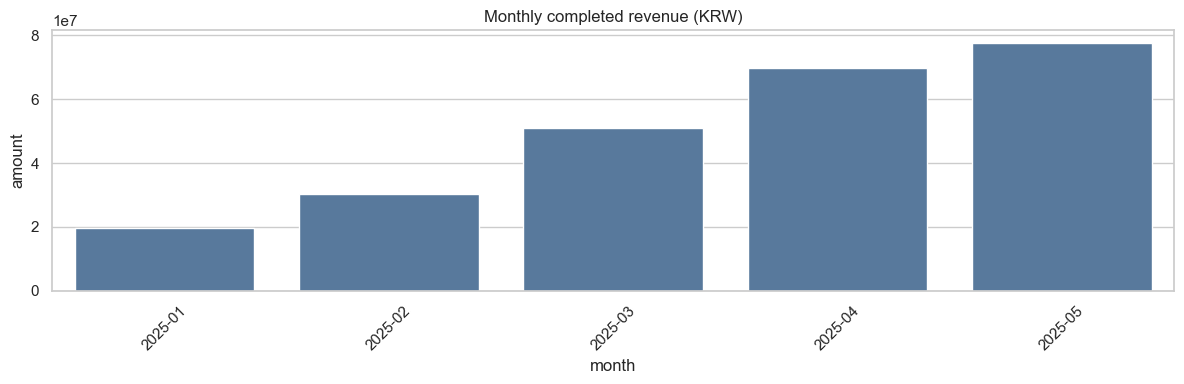

In [22]:
monthly_revenue = (
    payments.loc[payments['status'] == 'completed']
    .assign(month=lambda d: d['transaction_date'].dt.to_period('M').astype(str))
    .groupby('month', as_index=False)['amount'].sum()
)

plt.figure(figsize=(12, 4))
sns.barplot(data=monthly_revenue, x='month', y='amount', color='#4C78A8')
plt.title('Monthly completed revenue (KRW)')
plt.xticks(rotation=45)
plt.tight_layout()


## Pricing and Plan Mix EDA

In [23]:
# Plan-level mix from completed payments
completed_payments = payments.loc[payments['status'] == 'completed'].copy()

plan_mix = (
    completed_payments
    .groupby('plan_name', as_index=False)
    .agg(
        transactions=('transaction_id', 'count'),
        paid_users=('user_id', 'nunique'),
        revenue=('amount', 'sum')
    )
    .sort_values('revenue', ascending=False)
)

plan_mix['tx_share'] = plan_mix['transactions'] / plan_mix['transactions'].sum()
plan_mix['user_share'] = plan_mix['paid_users'] / plan_mix['paid_users'].sum()
plan_mix['revenue_share'] = plan_mix['revenue'] / plan_mix['revenue'].sum()

plan_mix


,plan_name,transactions,paid_users,revenue,tx_share,user_share,revenue_share
1,annual_pro,480,480,95520000,0.061602,0.097324,0.384232
0,annual_basic,677,677,67023000,0.086884,0.137267,0.269602
2,monthly_basic,4598,2903,45520200,0.590092,0.588605,0.183107
3,monthly_pro,2037,872,40536300,0.261422,0.176805,0.163059


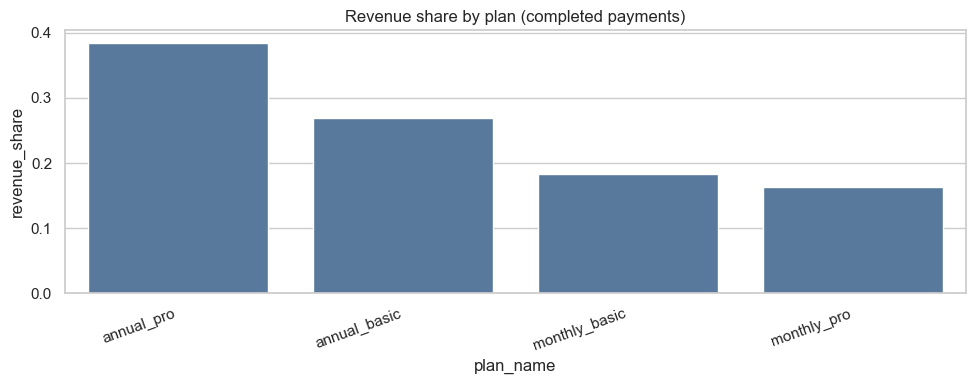

In [24]:
# Revenue share by plan_name
plt.figure(figsize=(10, 4))
sns.barplot(data=plan_mix, x='plan_name', y='revenue_share', color='#4C78A8')
plt.title('Revenue share by plan (completed payments)')
plt.ylabel('revenue_share')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()


In [25]:
# Basic vs Pro and Monthly vs Annual composition
plan_mix_tagged = plan_mix.copy()
plan_mix_tagged['tier'] = np.where(plan_mix_tagged['plan_name'].str.contains('pro'), 'pro', 'basic')
plan_mix_tagged['term'] = np.where(plan_mix_tagged['plan_name'].str.contains('annual'), 'annual', 'monthly')

mix_by_tier = plan_mix_tagged.groupby('tier', as_index=False)[['transactions', 'paid_users', 'revenue']].sum()
mix_by_tier['revenue_share'] = mix_by_tier['revenue'] / mix_by_tier['revenue'].sum()

mix_by_term = plan_mix_tagged.groupby('term', as_index=False)[['transactions', 'paid_users', 'revenue']].sum()
mix_by_term['revenue_share'] = mix_by_term['revenue'] / mix_by_term['revenue'].sum()

print('Mix by tier')
display(mix_by_tier)
print('Mix by term')
display(mix_by_term)


Mix by tier


,tier,transactions,paid_users,revenue,revenue_share
0,basic,5275,3580,112543200,0.452709
1,pro,2517,1352,136056300,0.547291


Mix by term


,term,transactions,paid_users,revenue,revenue_share
0,annual,1157,1157,162543000,0.653835
1,monthly,6635,3775,86056500,0.346165


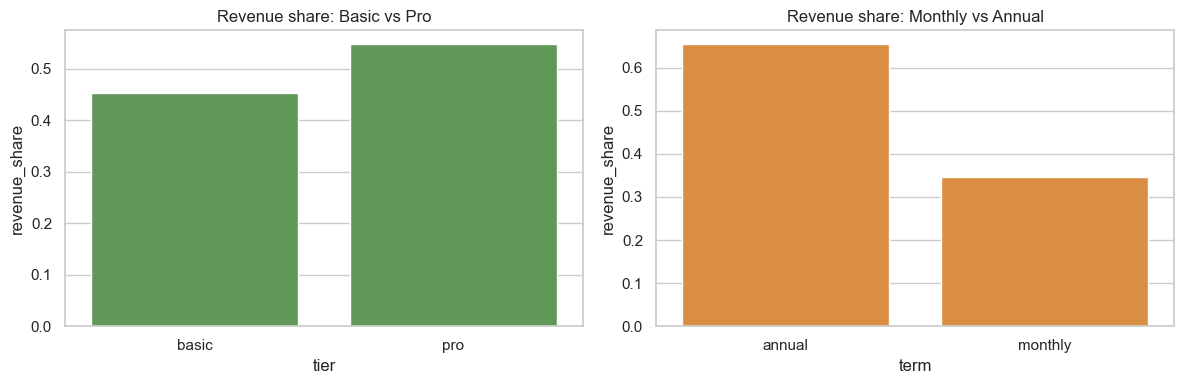

In [26]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=mix_by_tier, x='tier', y='revenue_share', ax=axes[0], color='#59A14F')
axes[0].set_title('Revenue share: Basic vs Pro')

sns.barplot(data=mix_by_term, x='term', y='revenue_share', ax=axes[1], color='#F28E2B')
axes[1].set_title('Revenue share: Monthly vs Annual')

plt.tight_layout()


In [27]:
# lessons
lessons.describe(include='all')


,lesson_id,course_id,lesson_order,title,duration_min,has_quiz
count,239,239,239.000000,239,239.000000,239
unique,239,20,NaN,76,NaN,2
top,LES-001,CRS-005,NaN,변수와 자료형,NaN,False
freq,1,20,NaN,5,NaN,164
mean,NaN,NaN,7.117155,NaN,16.267782,NaN
std,NaN,NaN,4.407175,NaN,7.792170,NaN
min,NaN,NaN,1.000000,NaN,5.000000,NaN
25%,NaN,NaN,3.500000,NaN,9.000000,NaN
50%,NaN,NaN,7.000000,NaN,16.000000,NaN
75%,NaN,NaN,10.000000,NaN,22.500000,NaN


In [28]:
top_counts(lessons, 'course_id', 20)


,count
course_id,
CRS-005,20
CRS-004,18
CRS-020,16
CRS-009,16
CRS-015,15
CRS-001,15
CRS-007,14
CRS-018,14
CRS-008,12


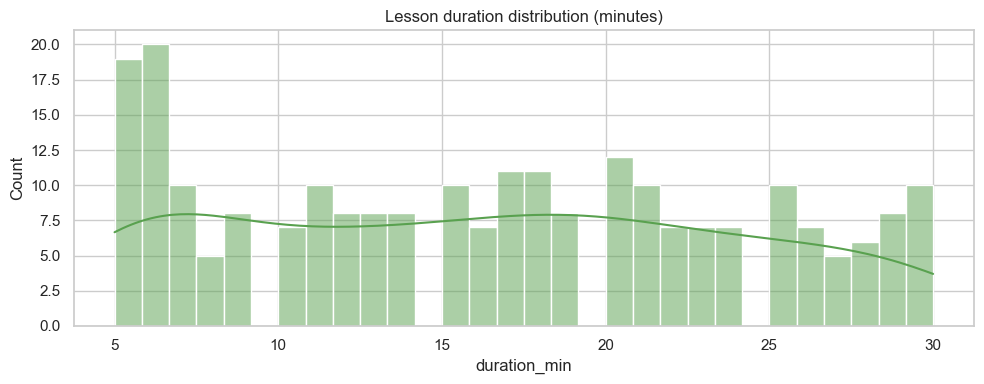

In [29]:
plt.figure(figsize=(10, 4))
sns.histplot(lessons['duration_min'].dropna(), bins=30, kde=True, color='#59A14F')
plt.title('Lesson duration distribution (minutes)')
plt.tight_layout()


## 7) Join coverage checks

In [30]:
users_set = set(users['user_id'].unique())
event_set = set(event_logs['user_id'].dropna().unique())
pay_set = set(payments['user_id'].dropna().unique())
plan_set = set(plan_history['user_id'].dropna().unique())

coverage = pd.DataFrame([
    ['event_logs in users', len(event_set & users_set), len(event_set), len(event_set - users_set)],
    ['payments in users', len(pay_set & users_set), len(pay_set), len(pay_set - users_set)],
    ['plan_history in users', len(plan_set & users_set), len(plan_set), len(plan_set - users_set)],
], columns=['check', 'matched_user_ids', 'source_user_ids', 'not_in_users'])

coverage


,check,matched_user_ids,source_user_ids,not_in_users
0,event_logs in users,17020,17020,0
1,payments in users,5002,5002,0
2,plan_history in users,5520,5520,0


## 8) Data integrity checks

### 8-1) `users` integrity

In [31]:
users_checks = {}

users_checks['duplicate_user_id'] = int(users['user_id'].duplicated().sum())

for col in ['user_id', 'signup_date', 'device_type', 'state']:
    users_checks[f'null_{col}'] = int(users[col].isna().sum())

valid_device = {'web', 'ios', 'android'}
users_checks['invalid_device_type'] = int(((~users['device_type'].isin(valid_device)) & users['device_type'].notna()).sum())

valid_state = {'trialing', 'active', 'free_active', 'churned', 'resurrected'}
users_checks['invalid_state'] = int(((~users['state'].isin(valid_state)) & users['state'].notna()).sum())

users_checks['activation_before_signup'] = int(((users['activation_date'] < users['signup_date']) & users['activation_date'].notna() & users['signup_date'].notna()).sum())
users_checks['churn_before_signup'] = int(((users['churn_date'] < users['signup_date']) & users['churn_date'].notna() & users['signup_date'].notna()).sum())
users_checks['last_active_before_signup'] = int(((users['last_active_date'] < users['signup_date']) & users['last_active_date'].notna() & users['signup_date'].notna()).sum())

pd.DataFrame(users_checks.items(), columns=['check', 'count'])


,check,count
0,duplicate_user_id,0
1,null_user_id,0
2,null_signup_date,0
3,null_device_type,0
4,null_state,0
5,invalid_device_type,0
6,invalid_state,0
7,activation_before_signup,0
8,churn_before_signup,0
9,last_active_before_signup,0


### 8-2) `event_logs` integrity

In [32]:
event_checks = {}

event_checks['fully_duplicated_rows'] = int(event_logs.duplicated().sum())

for col in ['user_id', 'session_id', 'event_name', 'event_timestamp']:
    event_checks[f'null_{col}'] = int(event_logs[col].isna().sum())

valid_device = {'web', 'ios', 'android'}
event_checks['invalid_device_type'] = int(((~event_logs['device_type'].isin(valid_device)) & event_logs['device_type'].notna()).sum())

event_checks['non_positive_event_sequence'] = int((event_logs['event_sequence'].fillna(0) <= 0).sum())
event_checks['user_id_not_in_users'] = int((~event_logs['user_id'].isin(users['user_id'])).sum())

pd.DataFrame(event_checks.items(), columns=['check', 'count'])


,check,count
0,fully_duplicated_rows,5490
1,null_user_id,0
2,null_session_id,9007
3,null_event_name,0
4,null_event_timestamp,0
5,invalid_device_type,0
6,non_positive_event_sequence,0
7,user_id_not_in_users,0


### 8-3) `payment_transactions` integrity

In [33]:
pay_checks = {}

pay_checks['duplicate_transaction_id'] = int(payments['transaction_id'].duplicated().sum())

for col in ['transaction_id', 'user_id', 'transaction_date', 'plan_name', 'amount', 'status']:
    pay_checks[f'null_{col}'] = int(payments[col].isna().sum())

valid_status = {'completed', 'failed'}
pay_checks['invalid_status'] = int(((~payments['status'].isin(valid_status)) & payments['status'].notna()).sum())

valid_plan = {'monthly_basic', 'monthly_pro', 'annual_basic', 'annual_pro'}
pay_checks['invalid_plan_name'] = int(((~payments['plan_name'].isin(valid_plan)) & payments['plan_name'].notna()).sum())

pay_checks['non_positive_amount'] = int((payments['amount'].fillna(0) <= 0).sum())
pay_checks['negative_retry_count'] = int((payments['retry_count'].fillna(0) < 0).sum())
pay_checks['failed_without_failure_reason'] = int(((payments['status'] == 'failed') & payments['failure_reason'].isna()).sum())
pay_checks['completed_with_failure_reason'] = int(((payments['status'] == 'completed') & payments['failure_reason'].notna()).sum())
pay_checks['user_id_not_in_users'] = int((~payments['user_id'].isin(users['user_id'])).sum())

pd.DataFrame(pay_checks.items(), columns=['check', 'count'])


,check,count
0,duplicate_transaction_id,0
1,null_transaction_id,0
2,null_user_id,0
3,null_transaction_date,0
4,null_plan_name,0
5,null_amount,0
6,null_status,0
7,invalid_status,0
8,invalid_plan_name,0
9,non_positive_amount,0


### 8-4) `plan_history` integrity

In [34]:
plan_checks = {}

for col in ['user_id', 'plan_name', 'action', 'action_date']:
    plan_checks[f'null_{col}'] = int(plan_history[col].isna().sum())

valid_action = {'subscribe', 'renew', 'upgrade', 'cancel'}
plan_checks['invalid_action'] = int(((~plan_history['action'].isin(valid_action)) & plan_history['action'].notna()).sum())

valid_plan = {'monthly_basic', 'monthly_pro', 'annual_basic', 'annual_pro'}
plan_checks['invalid_plan_name'] = int(((~plan_history['plan_name'].isin(valid_plan)) & plan_history['plan_name'].notna()).sum())

plan_checks['cancel_without_cancel_reason'] = int(((plan_history['action'] == 'cancel') & plan_history['cancel_reason'].isna()).sum())
plan_checks['upgrade_without_previous_plan'] = int(((plan_history['action'] == 'upgrade') & plan_history['previous_plan'].isna()).sum())
plan_checks['user_id_not_in_users'] = int((~plan_history['user_id'].isin(users['user_id'])).sum())

pd.DataFrame(plan_checks.items(), columns=['check', 'count'])


,check,count
0,null_user_id,0
1,null_plan_name,0
2,null_action,0
3,null_action_date,0
4,invalid_action,0
5,invalid_plan_name,0
6,cancel_without_cancel_reason,0
7,upgrade_without_previous_plan,0
8,user_id_not_in_users,0


### 8-5) `lessons` integrity

In [35]:
lesson_checks = {}

lesson_checks['duplicate_lesson_id'] = int(lessons['lesson_id'].duplicated().sum())

for col in ['lesson_id', 'course_id', 'lesson_order', 'duration_min']:
    lesson_checks[f'null_{col}'] = int(lessons[col].isna().sum())

lesson_checks['non_positive_lesson_order'] = int((lessons['lesson_order'].fillna(0) <= 0).sum())
lesson_checks['non_positive_duration_min'] = int((lessons['duration_min'].fillna(0) <= 0).sum())
lesson_checks['duplicate_lesson_order_within_course'] = int(lessons.duplicated(subset=['course_id', 'lesson_order']).sum())

pd.DataFrame(lesson_checks.items(), columns=['check', 'count'])


,check,count
0,duplicate_lesson_id,0
1,null_lesson_id,0
2,null_course_id,0
3,null_lesson_order,0
4,null_duration_min,0
5,non_positive_lesson_order,0
6,non_positive_duration_min,0
7,duplicate_lesson_order_within_course,0


### 8-6) Integrity issue summary

In [36]:
def nonzero(df, table_name):
    out = df.copy()
    out = out[out['count'] > 0].copy()
    out.insert(0, 'table', table_name)
    return out

issues = pd.concat([
    nonzero(pd.DataFrame(users_checks.items(), columns=['check', 'count']), 'users'),
    nonzero(pd.DataFrame(event_checks.items(), columns=['check', 'count']), 'event_logs'),
    nonzero(pd.DataFrame(pay_checks.items(), columns=['check', 'count']), 'payment_transactions'),
    nonzero(pd.DataFrame(plan_checks.items(), columns=['check', 'count']), 'plan_history'),
    nonzero(pd.DataFrame(lesson_checks.items(), columns=['check', 'count']), 'lessons'),
], ignore_index=True)

issues.sort_values(['table', 'count'], ascending=[True, False])


,table,check,count
1,event_logs,null_session_id,9007
0,event_logs,fully_duplicated_rows,5490


## 9) Next actions for Q1
- Use integrity outputs to define exclusion/correction rules
- Recompute activation -> paid conversion by device/channel
- Identify candidate Aha actions (lesson count, quiz actions, time-to-first-lesson)

## Metric Definition Update
`is_activated` now follows Activation(v2): user has at least one `lesson_started` event within 7 days from signup. `activation_date` is the first date this condition is met.